In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Principal Component Analysis

df = pd.read_csv("financial_loan_data.csv")

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2/11/2021,9/13/2021,4/13/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,12/14/2021,1/15/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,1/5/2021,12/12/2021,1/9/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2/25/2021,12/12/2021,3/12/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,12/14/2021,1/15/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [7]:
features = ['annual_income','dti','installment','int_rate','loan_amount','total_acc','total_payment']

In [9]:
X = df[features]

In [11]:
scaler = StandardScaler()

In [13]:
scaled_data = scaler.fit_transform(X)

In [15]:
scaled_data

array([[-0.61662443, -1.84928078, -1.27712407, ..., -1.17899481,
        -1.59167219, -1.24343875],
       [-0.33665549, -1.19672227, -1.03990484, ..., -1.11197652,
        -1.59167219, -0.91971717],
       [-0.30554783,  1.13298662,  0.45333281, ...,  0.0943528 ,
        -0.97721315, -0.96578949],
       ...,
       [-0.07224039,  0.601939  ,  1.43989697, ...,  1.83682848,
        -0.18719438,  2.5917229 ],
       [ 4.64056999, -1.98579302,  1.36715293, ...,  1.70279189,
        -1.15277288,  2.36589119],
       [ 0.16106706, -1.09921352,  0.76520914, ...,  0.89857234,
        -1.3283326 ,  1.70320106]])

In [17]:
pca = PCA(n_components = len(features))

In [19]:
X_pca = pca.fit_transform(scaled_data)

In [21]:
X_pca

array([[-2.35874012, -2.02131766, -0.95611453, ...,  0.72516152,
        -0.04770816,  0.08890705],
       [-1.71131236, -1.64083985, -1.50116046, ...,  0.53233336,
         0.0433097 , -0.07371065],
       [-0.16489843,  0.39464441, -1.50959354, ..., -0.70347747,
        -1.08622014, -0.03231042],
       ...,
       [ 3.44272749, -0.10732279, -1.45967515, ..., -0.16342803,
         0.81991621,  0.08840217],
       [ 3.93587188, -3.54087187,  1.4801998 , ..., -1.41696202,
         0.73452021,  0.10490772],
       [ 2.02971322, -2.00749058, -1.8257592 , ...,  0.35045838,
         0.67791679, -0.06995424]])

In [23]:
loadings = pd.DataFrame(
    pca.components_,
    index = features,
    columns = [f"PC{i+1}" for i in range(len(features))]
)

In [25]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
annual_income,0.222531,0.067496,0.531615,0.230235,0.540852,0.205367,0.524982
dti,-0.180191,0.799261,-0.082675,-0.047208,-0.063931,0.556863,-0.073933
installment,0.601292,-0.261203,-0.045387,-0.557033,-0.052244,0.499852,-0.072757
int_rate,0.596642,0.081170,-0.216002,0.718505,-0.192693,0.058824,-0.184210
loan_amount,-0.447707,-0.530824,-0.062191,0.342421,-0.027466,0.627505,-0.046350
total_acc,0.004319,-0.006063,-0.539995,-0.024748,-0.243790,0.006739,0.805145
total_payment,0.004201,0.000681,-0.605286,-0.019080,0.776752,-0.024648,-0.171158


In [29]:
#x-> annual_income,installment,int_rate,total_acc,total_payment
#Y -> dti,loan_amount

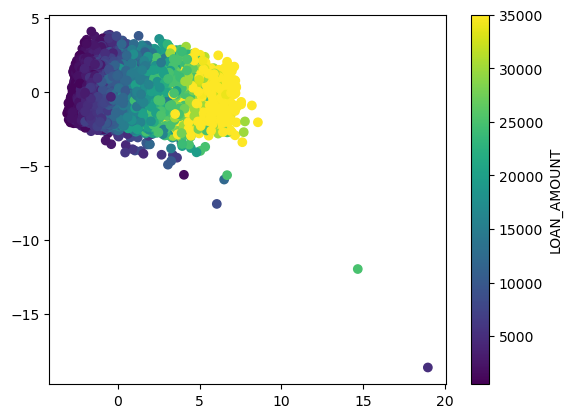

In [33]:
scatter = plt.scatter(X_pca[:,0],X_pca[:,1], c=df['loan_amount'])
plt.colorbar(scatter,label = 'LOAN_AMOUNT')